# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [ ]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

In [ ]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

## Si usan PyGAD:

In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

## Si usan DEAP:

In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

Iniciando optimización...
Optimización finalizada.

Mejor Cronograma Encontrado:
Días de inicio por tarea: [ 9  9  3  3 -4 -4 -3 -1  4 14]
Tiempo total de obra (Makespan): 16 días


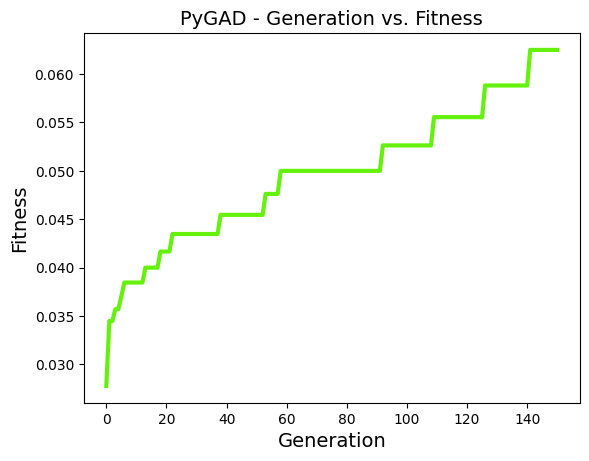

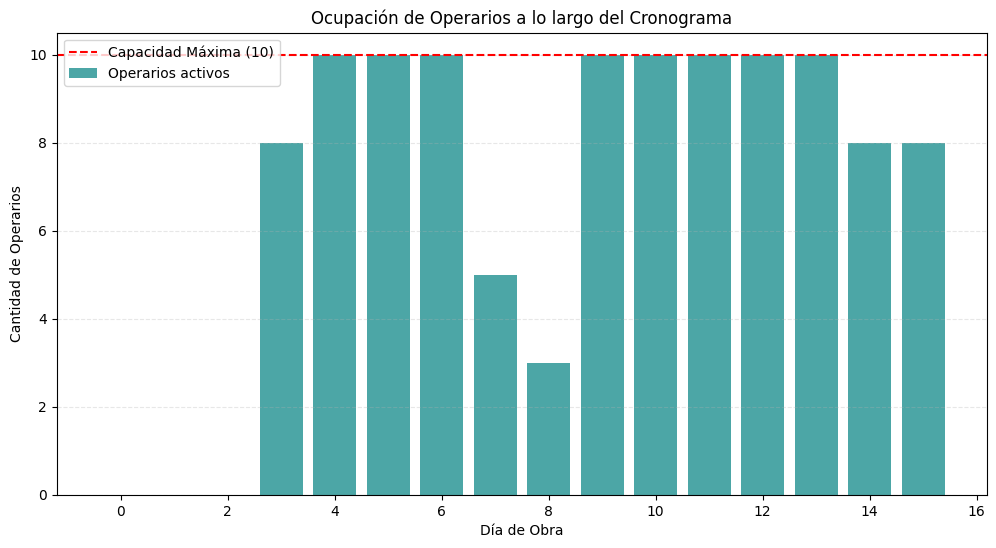

In [4]:
# Celda 1: Instalación de librerías
!pip install pygad matplotlib numpy

import pygad
import numpy as np
import matplotlib.pyplot as plt

# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

# Celda 3: Definición de la Función de Aptitud (Fitness)
def fitness_func(ga_instance, solution, solution_idx):
    # Los genes representan el día de inicio de cada tarea
    dias_inicio = np.round(solution).astype(int)

    dias_fin = []
    for i in range(NUM_TAREAS):
        duracion = TASAS_OBRA[i][0]
        dias_fin.append(dias_inicio[i] + duracion)

    total_dias = max(dias_fin)

    # Creamos un array que represente el uso de operarios en cada unidad de tiempo
    uso_operarios = np.zeros(total_dias + 1)

    for i in range(NUM_TAREAS):
        inicio = dias_inicio[i]
        fin = dias_fin[i]
        cantidad_ops = TASAS_OBRA[i][1]
        uso_operarios[inicio:fin] += cantidad_ops

    # Penalización: Si se supera el límite de 10 operarios, el fitness es muy bajo
    if np.any(uso_operarios > MAX_OPERARIOS):
        return 0.0001

    return 1.0 / total_dias

ga_instance = pygad.GA(
    num_generations=150,           # Cantidad de iteraciones
    num_parents_mating=10,         # Padres que pasan a la siguiente gen
    fitness_func=fitness_func,     # Función evaluadora
    sol_per_pop=100,               # Individuos por población
    num_genes=NUM_TAREAS,          # Un gen por tarea (día de inicio)
    init_range_low=0,              # Día mínimo de inicio
    init_range_high=40,            # Día máximo estimado de inicio
    gene_type=int,                 # Trabajamos con días enteros
    parent_selection_type="sss",   # Steady State Selection
    keep_parents=2,                # Elitismo
    mutation_percent_genes=10      # Probabilidad de mutación
)

print("Iniciando optimización...")
ga_instance.run()
print("Optimización finalizada.")

solution, solution_fitness, solution_idx = ga_instance.best_solution()

print("\n" + "="*40)
print(f"Mejor Cronograma Encontrado:")
print(f"Días de inicio por tarea: {solution}")
print(f"Tiempo total de obra (Makespan): {1 / solution_fitness:.0f} días")
print("="*40)

# Gráfica de evolución del Fitness
ga_instance.plot_fitness()

# Gráfica de carga de operarios diaria
dias_inicio = np.round(solution).astype(int)
dias_fin = [dias_inicio[i] + TASAS_OBRA[i][0] for i in range(NUM_TAREAS)]
total_dias = max(dias_fin)
uso_diario = np.zeros(total_dias)

for i in range(NUM_TAREAS):
    uso_diario[dias_inicio[i]:dias_fin[i]] += TASAS_OBRA[i][1]

plt.figure(figsize=(12, 6))
plt.bar(range(total_dias), uso_diario, color='teal', alpha=0.7, label='Operarios activos')
plt.axhline(y=MAX_OPERARIOS, color='red', linestyle='--', label='Capacidad Máxima (10)')
plt.title("Ocupación de Operarios a lo largo del Cronograma")
plt.xlabel("Día de Obra")
plt.ylabel("Cantidad de Operarios")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()